# Logistic Regression SOPP

In [ ]:
# Packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression


In [ ]:
sopp_df = pd.read_csv("sopp_inflated.csv")

In [ ]:
# Turn Year and Month into Categories
sopp_df['YEAR'] = sopp_df['YEAR'].astype('category')
sopp_df['MONTH'] = sopp_df['MONTH'].astype('category')

In [ ]:
sopp_df.head()

,date,time_segment,precinct,DAY_WEEK,STOP,MONTH,YEAR
0,2010-01-01,Late Night,CENTRAL,Friday,1,1,2010
1,2010-01-01,Late Night,EAST,Friday,1,1,2010
2,2010-01-01,Late Night,HERMITAGE,Friday,1,1,2010
3,2010-01-01,Late Night,MADISON,Friday,1,1,2010
4,2010-01-01,Late Night,MIDTOWN HILLS,Friday,1,1,2010


## Checking for Multicolinearity

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = pd.get_dummies(
    sopp_df[['precinct','time_segment','DAY_WEEK','YEAR','MONTH']],
    drop_first=True
)
X = X.astype(float)

import pandas as pd

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

                      Variable       VIF
0                precinct_EAST  1.766263
1           precinct_HERMITAGE  1.766263
2             precinct_MADISON  1.766263
3       precinct_MIDTOWN HILLS  1.766263
4               precinct_NORTH  1.766263
5               precinct_SOUTH  1.766263
6           precinct_SOUTHEAST  1.766263
7                precinct_WEST  1.766263
8   time_segment_Early Morning  1.844175
9         time_segment_Evening  1.844175
10     time_segment_Late Night  1.844175
11        time_segment_Morning  1.844175
12          time_segment_Night  1.844175
13             DAY_WEEK_Monday  1.817275
14           DAY_WEEK_Saturday  1.819450
15             DAY_WEEK_Sunday  1.818301
16           DAY_WEEK_Thursday  1.817529
17            DAY_WEEK_Tuesday  1.816397
18          DAY_WEEK_Wednesday  1.817556
19                   YEAR_2011  1.761218
20                   YEAR_2012  1.763542
21                   YEAR_2013  1.761222
22                   YEAR_2014  1.761218
23              

# Fitting the Model

## Model with Temporal Only

In [ ]:
from sklearn.model_selection import train_test_split

X = pd.get_dummies(sopp_df[['DAY_WEEK', 'time_segment', 'MONTH', "YEAR"]], drop_first=True)

# Target
y = sopp_df['STOP']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Fitting the Model and Results

In [ ]:
tem_model = LogisticRegression(max_iter=1000, class_weight = "balanced")
tem_model.fit(X_train, y_train)

y_prob = tem_model.predict_proba(X_test)[:, 1]
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

### Classification Report

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.23      0.70      0.34      3971
           1       0.95      0.71      0.81     32425

    accuracy                           0.71     36396
   macro avg       0.59      0.70      0.58     36396
weighted avg       0.87      0.71      0.76     36396



### ROC AUC

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob)

np.float64(0.7789242827771972)

### Confusion Matrix

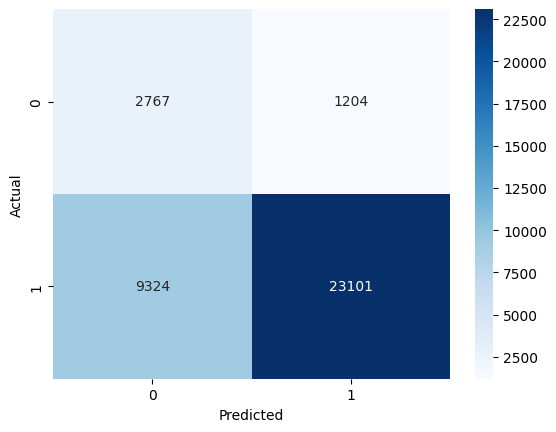

In [ ]:
from sklearn.metrics import confusion_matrix

# Generate the matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize it
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Feature Importance and Odds Ratio

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': tem_model.coef_[0],
    'Odds_Ratio': np.exp(tem_model.coef_[0]) # Essential for interpretation
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

                       Feature  Coefficient  Odds_Ratio
23                   YEAR_2012     0.925848    2.524007
24                   YEAR_2013     0.793075    2.210182
25                   YEAR_2014     0.519418    1.681048
10          time_segment_Night     0.449816    1.568023
22                   YEAR_2011     0.366533    1.442724
5           DAY_WEEK_Wednesday     0.361719    1.435795
7         time_segment_Evening     0.270880    1.311117
9         time_segment_Morning     0.163414    1.177524
4             DAY_WEEK_Tuesday     0.121280    1.128941
13                     MONTH_4     0.116333    1.123370
3            DAY_WEEK_Thursday     0.111204    1.117622
12                     MONTH_3     0.070939    1.073516
15                     MONTH_6     0.023294    1.023567
26                   YEAR_2015     0.009948    1.009998
17                     MONTH_8    -0.059636    0.942107
16                     MONTH_7    -0.075748    0.927050
11                     MONTH_2    -0.094714    0

## Model with Precinct

In [ ]:
# Sort by time
sopp_df = sopp_df.sort_values("date")

X = pd.get_dummies(sopp_df[['precinct', 'DAY_WEEK', 'time_segment', 'MONTH', 'YEAR']], drop_first=True)

# Target
y = sopp_df['STOP']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
pre_model = LogisticRegression(max_iter=1000, class_weight = "balanced")
pre_model.fit(X_train, y_train)

y_prob = pre_model.predict_proba(X_test)[:, 1]
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

### Classification Report

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.25      0.73      0.37      3971
           1       0.96      0.73      0.83     32425

    accuracy                           0.73     36396
   macro avg       0.60      0.73      0.60     36396
weighted avg       0.88      0.73      0.78     36396



### ROC AUC

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob)

np.float64(0.802025401198007)

### Confusion Matrix

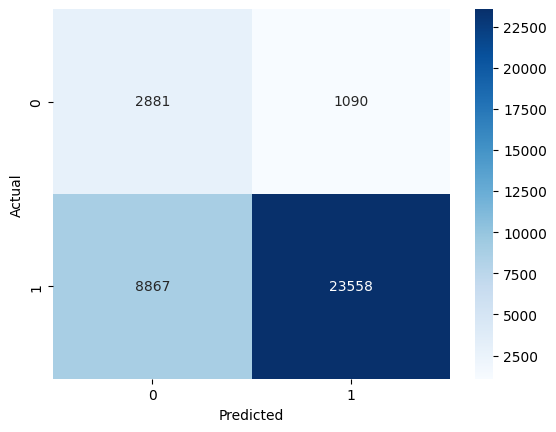

In [ ]:
from sklearn.metrics import confusion_matrix

# Generate the matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize it
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Feature Importance and Odds Ratios

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': pre_model.coef_[0],
    'Odds_Ratio': np.exp(pre_model.coef_[0]) # Essential for interpretation
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

                       Feature  Coefficient  Odds_Ratio
5               precinct_SOUTH     1.029226    2.798900
3       precinct_MIDTOWN HILLS     1.001633    2.722725
31                   YEAR_2012     0.953857    2.595703
32                   YEAR_2013     0.869556    2.385851
0                precinct_EAST     0.844560    2.326955
1           precinct_HERMITAGE     0.584232    1.793613
33                   YEAR_2014     0.546288    1.726832
18          time_segment_Night     0.499207    1.647415
30                   YEAR_2011     0.406686    1.501833
13          DAY_WEEK_Wednesday     0.377342    1.458404
7                precinct_WEST     0.316485    1.372296
15        time_segment_Evening     0.287685    1.333337
17        time_segment_Morning     0.176640    1.193201
21                     MONTH_4     0.158508    1.171761
12            DAY_WEEK_Tuesday     0.120027    1.127528
11           DAY_WEEK_Thursday     0.119526    1.126963
20                     MONTH_3     0.103352    1